--- ANÁLISIS TÉCNICO EDAN ---
Intensidad estimada para T=100 años: 127.05 mm/h
Riesgo de excedencia en 100 años: 63.40%


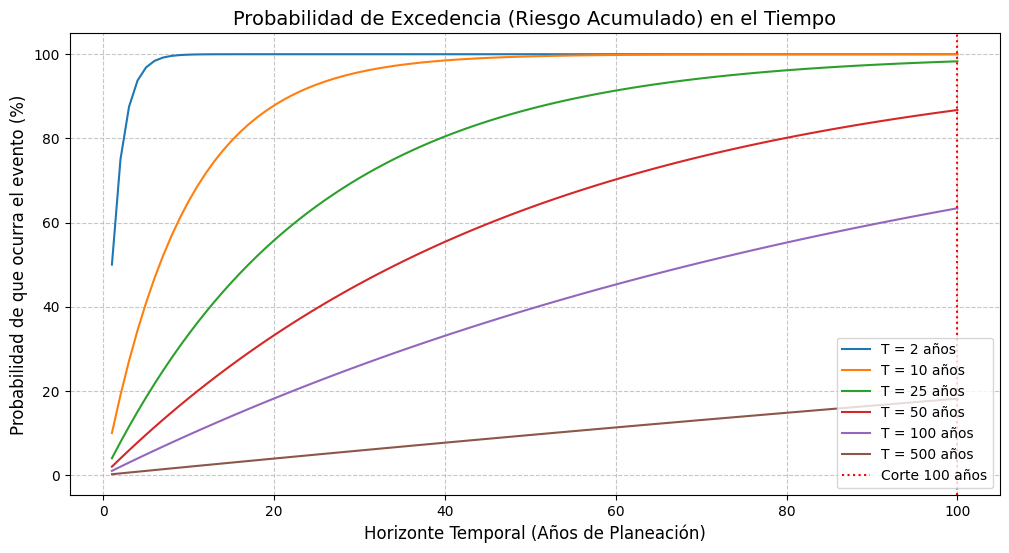

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

def calcular_gumbel_intensidad(periodo_retorno, media_historica, desviacion_estandar):
    """
    Calcula la intensidad de precipitación para un periodo de retorno T
    usando la distribución de Gumbel.
    """
    # Factor de frecuencia K para Gumbel (aproximación para muestras grandes)
    # y = -ln(-ln(1 - 1/T))
    y_t = -np.log(-np.log(1 - 1/periodo_retorno))

    # Parámetros de la distribución (basados en momentos)
    # alpha = (sqrt(6) * s) / pi
    # u = media - 0.5772 * alpha
    alpha = (np.sqrt(6) * desviacion_estandar) / np.pi
    u = media_historica - 0.5772 * alpha

    intensidad = u + (alpha * y_t)
    return intensidad

def calcular_riesgo_acumulado(periodo_retorno, horizonte_temporal):
    """
    Calcula la probabilidad de que el evento ocurra al menos una vez
    en un periodo de 'n' años.
    """
    probabilidad_anual = 1 / periodo_retorno
    riesgo = 1 - (1 - probabilidad_anual)**horizonte_temporal
    return riesgo * 100 # Retorna porcentaje

# --- CONFIGURACIÓN DE ESCENARIO ---
# Basado en la comunidad de 2,000 habitantes
media_lluvia = 80       # mm/h (común)
desviacion = 15        # mm/h (variabilidad estimada)
años_horizonte = 100    # Horizonte de planeación

# 1. Cálculo de Magnitud para T=100 años
t_objetivo = 100
intensidad_100 = calcular_gumbel_intensidad(t_objetivo, media_lluvia, desviacion)

# 2. Cálculo de Riesgo Acumulado
riesgo_100 = calcular_riesgo_acumulado(t_objetivo, años_horizonte)

print(f"--- ANÁLISIS TÉCNICO EDAN ---")
print(f"Intensidad estimada para T={t_objetivo} años: {intensidad_100:.2f} mm/h")
print(f"Riesgo de excedencia en {años_horizonte} años: {riesgo_100:.2f}%")

# --- VISUALIZACIÓN DE RIESGO ---
periodos = [2, 10, 25, 50, 100, 500]
horizonte_eje = np.arange(1, 101)

plt.figure(figsize=(12, 6))

for t in periodos:
    riesgos_linea = [calcular_riesgo_acumulado(t, n) for n in horizonte_eje]
    plt.plot(horizonte_eje, riesgos_linea, label=f'T = {t} años')

plt.title('Probabilidad de Excedencia (Riesgo Acumulado) en el Tiempo', fontsize=14)
plt.xlabel('Horizonte Temporal (Años de Planeación)', fontsize=12)
plt.ylabel('Probabilidad de que ocurra el evento (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=100, color='red', linestyle=':', label='Corte 100 años')
plt.legend()
plt.show()